# 01 · Calidad de datos, pipeline y variables derivadas — Caso 15 · Caja Rural 360

Continúa el trabajo del notebook 00_negocio_y_poblacion: parte de la **población PD ya definida** (`data.pd_population`) y del **catálogo de variables** (qué está disponible en T0 y qué está prohibido), y sobre esa base construye el perfilado de calidad, el pipeline de tratamiento y las variables derivadas. La narrativa está en `reports/03_data_strategy_calidad_features.md`.

| Sección | Contenido |
|---|---|
| 1 | Punto de partida: población y variables heredadas de 6.2 |
| 2 | Completitud |
| 3 | Duplicidad |
| 4 | Consistencia y lógica de negocio |
| 5 | Rangos y outliers |
| 6 | Cardinalidad |
| 7 | Estabilidad temporal de variables y del target |
| 8 | Variables derivadas: construcción, documentación y evaluación |
| 9 | Pipeline reproducible de faltantes y categóricas |
| 10 | Data Dictionary técnico |
| 11 | Persistencia y resumen de decisiones |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, data_dictionary, features, pipeline, quality, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: C:\Users\USUARIO\Downloads\Proyecto_Final_Credit_Scoring\credit-risk-capstone


## 1. Punto de partida: lo que viene de 6.2

El perfilado se hace sobre la **población PD** (aprobados con resultado observado) y, cuando el control lo requiere, sobre la base completa de solicitudes (TTD). Las variables a perfilar son las **candidatas** del catálogo: las disponibles en T0 y no prohibidas por leakage.

In [2]:
raw = data.load_raw()
pop, _ = data.pd_population(raw)
pop["year"] = pop[cfg.DATE_COL].dt.year

candidatas = data.pd_candidate_features()
cat_cols = ["region", "channel", "employment_type"]
num_cands = [c for c in candidatas if c not in cat_cols]

print(f"Solicitudes totales (TTD): {len(raw):,} | Población PD: {len(pop):,} | Default: {pop[cfg.TARGET].mean():.2%}")
print(f"Variables candidatas heredadas de 6.2: {len(candidatas)} ({len(num_cands)} numéricas, {len(cat_cols)} categóricas)")
print("Prohibidas por leakage/endogeneidad:", data.forbidden_pd_features())

Solicitudes totales (TTD): 7,000 | Población PD: 5,783 | Default: 11.60%
Variables candidatas heredadas de 6.2: 20 (17 numéricas, 3 categóricas)
Prohibidas por leakage/endogeneidad: ['annual_interest_rate_offer', 'approved_flag', 'outcome_available_flag', 'default_12m_flag', 'ead_at_default', 'balance_at_default', 'recovery_amount_total', 'recovery_cost_total', 'months_to_recovery', 'lgd_observed']


## 2. Completitud

Se mide sobre la población PD y abierta por muestra temporal, para verificar que el faltante no aparezca ni desaparezca con el tiempo (lo que obligaría a imputar distinto en producción).

In [3]:
comp = quality.completeness(pop, candidatas, by="sample")[["DEV", "VAL", "OOT", "total"]]
display(comp[comp["total"] > 0])
print("Variables sin ningún faltante:", int((comp["total"] == 0).sum()), "de", len(comp))
comp.to_csv(cfg.TABLES / "calidad_completitud.csv")

,DEV,VAL,OOT,total
savings_balance,0.0741,0.0782,0.0849,0.0771
bureau_score,0.0366,0.0313,0.0261,0.0334
monthly_income,0.0247,0.0235,0.0278,0.0251


Variables sin ningún faltante: 17 de 20


Solo tres variables tienen faltantes y ninguna supera el 8%: `savings_balance` (7.7%), `bureau_score` (3.3%) y `monthly_income` (2.5%). La tasa es **estable entre muestras** (por ejemplo, buró: 3.7% en DEV, 3.1% en VAL, 2.6% en OOT), así que la regla de imputación ajustada en DEV sigue siendo válida en las cosechas siguientes.

Las tres tienen faltante **informativo**, no aleatorio: no tener score de buró identifica a un cliente thin-file y no tener saldo de ahorros identifica a quien no tiene ese producto en la Caja. Por eso, además de imputar, se crean indicadores de faltante (sección 8) para que el modelo pueda distinguir esos perfiles.

## 3. Duplicidad

In [4]:
clave_negocio = [cfg.DATE_COL, "age", "region", "channel", "employment_type", "monthly_income", "requested_amount"]
display(quality.duplicates_report(raw, clave_negocio))

,control,registros,pct
0,Identificador duplicado (application_id),0,0.0000
1,Fila idéntica en todas las columnas (sin ID),0,0.0000
2,Clave de negocio duplicada (observation_date +...,0,0.0000


No hay duplicados de identificador, ni filas repetidas, ni solicitudes con la misma combinación de fecha, perfil y monto. No se requiere deduplicación.

## 4. Consistencia y lógica de negocio

Cada regla marca **violaciones**: mientras más cerca de cero, mejor. Se evalúan tanto reglas aritméticas (que una variable derivada del archivo cuadre con sus insumos) como reglas de negocio (edad de elegibilidad, coherencia entre campos post-default, plausibilidad del ingreso).

In [5]:
reglas = quality.consistency_rules(pop)
display(reglas[["regla", "severidad", "violaciones", "pct", "tratamiento"]])
reglas.to_csv(cfg.TABLES / "calidad_reglas_consistencia.csv", index=False)
print("Reglas evaluadas:", len(reglas), "| con violaciones:", int((reglas.violaciones > 0).sum()))

,regla,severidad,violaciones,pct,tratamiento
3,relación con la Caja <= (edad - 18) * 12,Baja,160,0.0277,Se conserva: es plausible una cuenta de ahorro...
17,"ingreso mensual >= S/ 1,025 (referencia)",Informativa,103,0.0178,Se conservan: en el segmento rural informal un...
2,antigüedad laboral <= (edad - 14) * 12,Media,81,0.0140,Se conserva el registro; la derivada antigueda...
16,cuota estimada <= ingreso mensual,Alta,1,0.0002,Caso aislado: la solicitud es inviable por cap...
0,dti = cuota de deuda / ingreso,Alta,0,0.0000,Sin violaciones: el dti del archivo es coheren...
1,new_customer_flag = 1 <-> relationship_months = 0,Alta,0,0.0000,Sin violaciones.
6,"cash_income_share dentro de [0, 1]",Alta,0,0.0000,Sin violaciones.
7,dti <= 1,Alta,0,0.0000,Sin violaciones.
9,plazo dentro del catálogo del producto,Alta,0,0.0000,Sin violaciones.
10,"bureau_score dentro de [300, 900]",Alta,0,0.0000,Sin violaciones.


Reglas evaluadas: 19 | con violaciones: 4


De 19 reglas, **15 se cumplen sin excepción** y 4 arrojan hallazgos, ninguno bloqueante:

1. **`relationship_months` mayor a la edad adulta posible (160 casos, 2.8%).** Severidad baja: es plausible que la relación con la Caja haya empezado con una cuenta de ahorros antes de los 18 años. Se conservan.
2. **Ingreso menor a la referencia de S/ 1,025 (103 casos, 1.8%).** No es un error: en un segmento rural informal un ingreso por debajo del salario mínimo formal es perfectamente plausible. Se conserva sin tratamiento.
3. **Antigüedad laboral mayor a la vida laboral posible (81 casos, 1.4%).** Se conservan los registros ya que serían clientes del sector informal: la derivada `antiguedad_relativa` se acota a 1 y la winsorización limita el extremo.
4. **Cuota estimada mayor al ingreso mensual (1 caso).** La solicitud es inviable por capacidad de pago.

## 5. Rangos y outliers

Se usa la regla de Tukey con k = 3 (muy por fuera del rango intercuartílico) para no confundir la cola natural de una cartera de microcrédito con errores.

In [6]:
out = quality.outlier_report(pop, num_cands)
display(out[["variable", "min", "p1", "mediana", "p99", "max", "asimetria", "outliers_iqr", "pct_outliers"]])
out.to_csv(cfg.TABLES / "calidad_outliers.csv", index=False)

,variable,min,p1,mediana,p99,max,asimetria,outliers_iqr,pct_outliers
9,savings_balance,45.3700,217.7748,"2,666.9000","29,199.6860","243,909.3900",11.2204,176,0.0330
14,distance_to_branch_km,0.5000,1.4000,9.0000,55.5360,150.0000,3.1862,123,0.0213
7,monthly_debt_payment,3.8200,66.1930,861.7900,"5,158.7510","21,395.7100",3.1576,78,0.0135
12,requested_amount,512.0100,"1,341.8184","6,314.3300","29,992.1476","78,915.4700",2.6536,74,0.0128
1,monthly_income,529.2300,909.5519,"3,472.3650","12,725.3076","33,678.1500",1.9607,37,0.0066
2,employment_tenure_months,0.0000,4.0000,36.0000,124.1800,240.0000,1.2315,12,0.0021
11,relationship_months,0.0000,0.0000,13.0000,111.0000,180.0000,1.4136,9,0.0016
4,prior_delinquencies_24m,0.0000,0.0000,0.0000,3.0000,5.0000,1.4144,5,0.0009
6,active_loans,0.0000,0.0000,2.0000,6.0000,10.0000,0.6838,1,0.0002
0,age,18.0000,18.0000,38.0000,61.0000,71.0000,0.1066,0,0.0000


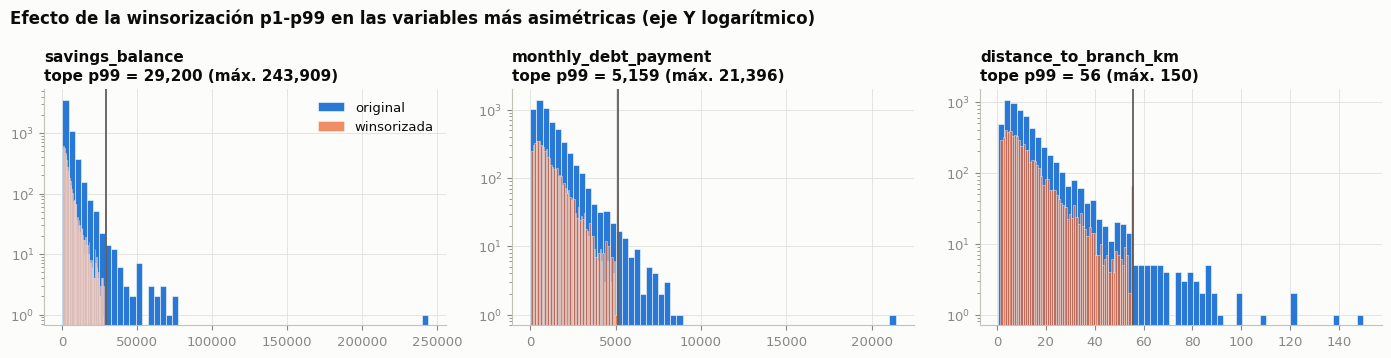

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col in zip(axes, ["savings_balance", "monthly_debt_payment", "distance_to_branch_km"]):
    s = pop[col].dropna()
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    ax.hist(s, bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.4, label="original")
    ax.hist(s.clip(lo, hi), bins=60, color=ORANGE, alpha=0.75, edgecolor=SURFACE, linewidth=0.4, label="winsorizada")
    ax.axvline(hi, color=INK_2, lw=1.2)
    ax.set_title(f"{col}\ntope p99 = {hi:,.0f} (máx. {s.max():,.0f})")
    ax.set_yscale("log")
axes[0].legend(loc="upper right")
fig.suptitle("Efecto de la winsorización p1-p99 en las variables más asimétricas (eje Y logarítmico)",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.tight_layout()
savefig(fig, "fig08_winsorizacion")
plt.show()

Los mínimos y máximos están dentro de rangos plausibles del producto. También hay **colas largas**: `savings_balance` llega a S/ 243,909 (asimetría 11.2) frente a una mediana de S/ 2,667, y 3.3% de los registros quedan fuera del rango de Tukey. Le siguen `distance_to_branch_km` (2.1%) y `monthly_debt_payment` (1.4%).

**Decisión:** no se eliminan outliers (son clientes reales del producto y borrarlos sesgaría la PD), sino que se **acotan a p1-p99 dentro del pipeline**, con topes ajustados en DEV. Así un valor extremo no domina el ajuste de un modelo lineal, pero el registro conserva su información de riesgo.

## 6. Cardinalidad

In [8]:
card = quality.cardinality_report(pop, candidatas)
display(card)
card.to_csv(cfg.TABLES / "calidad_cardinalidad.csv", index=False)

,variable,tipo,n_unicos,pct_unicos,categorias_menores_al_umbral
13,new_customer_flag,int64,2,0.0003,
3,employment_type,object,4,0.0007,
2,channel,object,4,0.0007,
1,region,object,5,0.0009,
7,prior_delinquencies_24m,int64,6,0.0010,"3 (1.6%), 4 (0.2%), 5 (0.1%)"
16,term_months,float64,8,0.0014,
18,household_dependents,int64,9,0.0016,"5 (4.9%), 6 (1.7%), 7 (0.6%), 8 (0.1%)"
8,bureau_inquiries_6m,int64,10,0.0017,"5 (2.5%), 6 (0.6%), 7 (0.3%), 8 (0.0%), 9 (0.0%)"
9,active_loans,int64,11,0.0019,"5 (3.9%), 6 (1.4%), 7 (0.2%), 8 (0.1%), 10 (0...."
0,age,int64,54,0.0093,


Las tres variables categóricas tienen cardinalidad baja y manejable (4 a 5 niveles), y **ninguna categoría baja del 7%** de la población, así que no hace falta agrupar categorías raras ni aplicar encodings de alta cardinalidad: un one-hot simple es suficiente y mantiene la interpretabilidad.

Entre las numéricas, `cash_income_share`, `requested_amount`, `monthly_debt_payment`, `monthly_income` y `savings_balance` son prácticamente continuas (más del 90% de valores únicos), mientras que `prior_delinquencies_24m`, `bureau_inquiries_6m`, `active_loans` y `household_dependents` son discretas con pocos niveles, lo que las hace buenas candidatas a agrupación en el scorecard.

## 7. Estabilidad temporal de las variables y del target

Se mide con PSI tomando DEV como referencia. Umbrales estándar: menor a 0.10 estable, entre 0.10 y 0.25 alerta, mayor a 0.25 cambio material.

In [9]:
estab = quality.temporal_stability(pop, candidatas, cat_cols)
display(estab)
estab.to_csv(cfg.TABLES / "calidad_estabilidad_psi.csv", index=False)
print("Variables con PSI OOT >= 0.10:", int((estab["psi_oot"] >= 0.10).sum()))

target_estab = quality.target_stability(pop)
display(target_estab)

,variable,psi_val,psi_oot,semaforo
0,age,0.0143,0.0174,Verde
15,requested_amount,0.0088,0.0128,Verde
5,employment_tenure_months,0.0200,0.0128,Verde
6,bureau_score,0.0065,0.0114,Verde
11,dti,0.0025,0.0100,Verde
12,savings_balance,0.0066,0.0098,Verde
4,monthly_income,0.0104,0.0077,Verde
2,channel,0.0023,0.0072,Verde
14,relationship_months,0.0083,0.0055,Verde
19,cash_income_share,0.0066,0.0055,Verde


Variables con PSI OOT >= 0.10: 0


,creditos,defaults,default_rate,var_vs_periodo_previo
observation_date,,,,
2021,1181,102,0.0864,NaN
2022,1146,111,0.0969,0.1215
2023,1116,138,0.1237,0.2767
2024,1151,161,0.1399,0.1312
2025,1189,159,0.1337,-0.0440


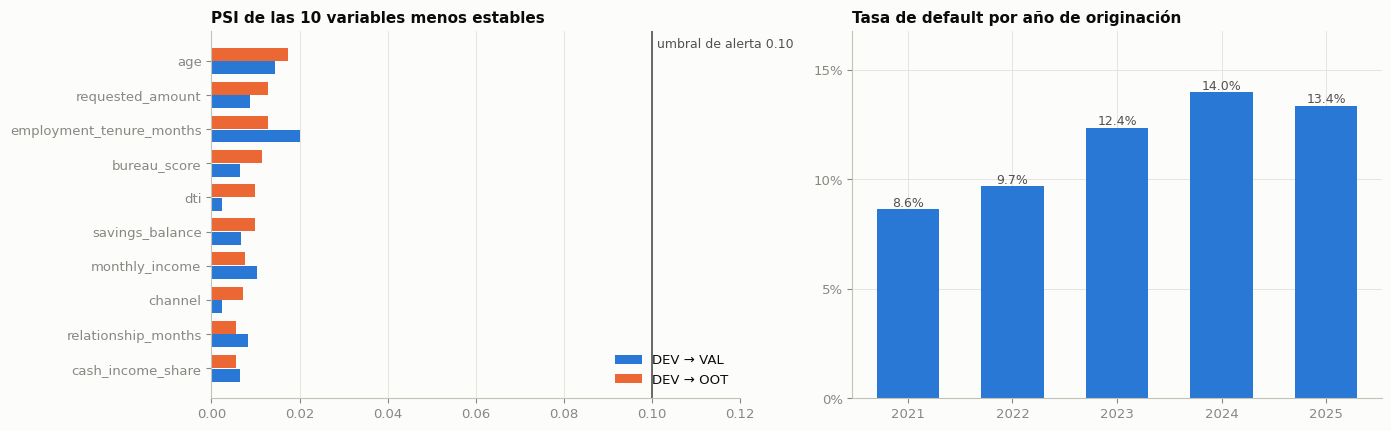

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
top = estab.head(10).iloc[::-1]
y = np.arange(len(top))
axes[0].barh(y - 0.2, top["psi_val"], height=0.38, color=BLUE, label="DEV → VAL")
axes[0].barh(y + 0.2, top["psi_oot"], height=0.38, color=ORANGE, label="DEV → OOT")
axes[0].axvline(0.10, color=INK_2, lw=1.2)
axes[0].text(0.101, len(top) - 0.6, "umbral de alerta 0.10", color=INK_2, fontsize=9)
axes[0].set_yticks(y, top["variable"])
axes[0].set_xlim(0, 0.12)
axes[0].set_title("PSI de las 10 variables menos estables")
axes[0].legend(loc="lower right")
axes[0].grid(axis="y", visible=False)

t = target_estab.reset_index()
t["anio"] = t[cfg.DATE_COL].astype(str)
axes[1].bar(t["anio"], t["default_rate"], color=BLUE, width=0.6)
for x_, v in enumerate(t["default_rate"]):
    axes[1].text(x_, v, f"{v:.1%}", ha="center", va="bottom", color=INK_2, fontsize=9)
axes[1].set_title("Tasa de default por año de originación")
pct_axis(axes[1])
axes[1].set_ylim(0, t["default_rate"].max() * 1.2)
fig.tight_layout()
savefig(fig, "fig09_estabilidad_temporal")
plt.show()

**Las variables son estables; el target no.** El PSI máximo es 0.017 (`age`), muy por debajo del umbral de alerta: el perfil de quien solicita el crédito prácticamente no cambió entre 2021 y 2025. En cambio, la tasa de default sube de 8.6% a 14.0% y cierra en 13.4%, con un salto de +27.7% en 2023 y +13.1% en 2024.

Esto confirma con datos de calidad lo que ya se había detectado en 6.2: **el cambio es del entorno, no de la población**. Para el modelamiento significa que (a) no hace falta re-ajustar transformaciones ni imputaciones por drift de variables, y (b) sí hará falta recalibrar el nivel de PD, porque el mismo perfil de cliente incumple más que antes.

## 8. Variables derivadas

Cada variable tiene fórmula, racional de negocio y signo esperado. Todas se calculan solo con insumos de T0 y sin estadísticos de la muestra, para que el mismo código funcione en producción.

In [11]:
doc = features.feature_doc()
display(doc)
doc.to_csv(cfg.TABLES / "features_derivadas_doc.csv", index=False)

pop_fx = features.build_features(pop)
print("Variables derivadas creadas:", len(features.DERIVED_FEATURES))
display(pop_fx[features.DERIVED_FEATURES].describe(percentiles=[.01, .5, .99]).T)

,feature,formula,racional,signo_esperado,uso
0,cuota_estimada,"monto * r / (1 - (1+r)^-plazo), con r = (1+TEA...",Cuota mensual del crédito solicitado. Es el in...,-,Insumo (no predictor)
1,ingreso_verificable,monthly_income * (1 - cash_income_share),"Parte del ingreso con trazabilidad (depósitos,...",-,Insumo (no predictor)
2,dti_post,(monthly_debt_payment + cuota_estimada) / mont...,Carga de deuda total si se aprueba el crédito....,+,Predictor y regla de política
3,dti_post_verificable,(monthly_debt_payment + cuota_estimada) / ingr...,Versión exigente del DTI: mide la carga contra...,+,Predictor
4,excedente_per_capita,(monthly_income - monthly_debt_payment - cuota...,Excedente mensual por miembro del hogar tras p...,-,Predictor
5,colchon_ahorro_meses,savings_balance / cuota_estimada,Cuántas cuotas podría pagar el cliente con sus...,-,Predictor
6,ahorro_sobre_monto,savings_balance / requested_amount,Capacidad de ahorro frente al tamaño del crédi...,-,Predictor
7,deuda_por_obligacion,monthly_debt_payment / (1 + active_loans),Cuota promedio por obligación vigente. Separa ...,+,Predictor
8,intensidad_busqueda,bureau_inquiries_6m / (1 + active_loans),Consultas al buró por obligación vigente. Much...,+,Predictor
9,antiguedad_relativa,"employment_tenure_months / ((age - 14) * 12), ...",Qué proporción de su vida laboral posible llev...,-,Predictor


Variables derivadas creadas: 14


,count,mean,std,min,1%,50%,99%,max
cuota_estimada,"5,783.0000",617.7819,655.6923,19.8382,57.5117,401.4953,"3,094.7183","8,135.9195"
ingreso_verificable,"5,638.0000","1,660.4874","1,395.3139",10.2242,118.6443,"1,267.1801","6,787.3456","14,745.8848"
dti_post,"5,638.0000",0.4337,0.1948,0.0488,0.1025,0.4140,0.9599,1.3696
dti_post_verificable,"5,638.0000",1.5831,1.6301,0.0803,0.2041,1.0509,10.0000,10.0000
excedente_per_capita,"5,638.0000",936.1843,976.2126,-749.8943,25.4795,648.2553,"4,925.9123","13,687.9265"
colchon_ahorro_meses,"5,337.0000",11.8514,16.6848,0.0758,0.4779,6.5104,84.2907,311.9271
ahorro_sobre_monto,"5,337.0000",0.6548,0.7452,0.0123,0.0460,0.4164,3.8058,9.4365
deuda_por_obligacion,"5,783.0000",495.1489,584.4037,0.6367,19.3452,312.5300,"2,824.7351","8,173.3600"
intensidad_busqueda,"5,783.0000",0.7660,0.7918,0.0000,0.0000,0.5000,4.0000,7.0000
antiguedad_relativa,"5,783.0000",0.1810,0.1734,0.0000,0.0126,0.1310,1.0000,1.0000


### Evaluación: ¿aportan señal?

Se mide el AUC univariado en cada muestra (capacidad de ordenar riesgo por sí sola) y el PSI DEV→OOT (estabilidad). El criterio no es solo el AUC: una variable con poca señal puede quedarse si es necesaria para la política (como `dti_post`, que sostiene la regla de capacidad de pago) o si su faltante es informativo.

In [12]:
def evalua(df, cols):
    filas = []
    for c in cols:
        d, v, o = (df[df["sample"] == s] for s in cfg.SAMPLE_ORDER)
        filas.append({
            "variable": c,
            "auc_dev": validation.univariate_auc(d[cfg.TARGET], d[c]),
            "auc_val": validation.univariate_auc(v[cfg.TARGET], v[c]),
            "auc_oot": validation.univariate_auc(o[cfg.TARGET], o[c]),
            "psi_oot": validation.psi(d[c], o[c]),
            "pct_na": df[c].isna().mean(),
        })
    return pd.DataFrame(filas).sort_values("auc_dev", ascending=False)

ev_new = evalua(pop_fx, features.DERIVED_CANDIDATES).assign(origen="Derivada 6.3")
ev_base = evalua(pop_fx, ["bureau_score", "dti", "prior_delinquencies_24m", "cash_income_share",
                          "monthly_income", "requested_amount"]).assign(origen="Original")
ev = pd.concat([ev_new, ev_base]).sort_values("auc_dev", ascending=False)
display(ev)
ev.to_csv(cfg.TABLES / "features_evaluacion.csv", index=False)

,variable,auc_dev,auc_val,auc_oot,psi_oot,pct_na,origen
0,bureau_score,0.6934,0.6733,0.7074,0.0114,0.0334,Original
1,dti,0.5706,0.5328,0.6131,0.0100,0.0000,Original
0,dti_post,0.5701,0.5381,0.5799,0.0067,0.0251,Derivada 6.3
1,dti_post_verificable,0.5474,0.5256,0.5549,0.0051,0.0251,Derivada 6.3
5,deuda_por_obligacion,0.5443,0.5546,0.5731,0.0018,0.0000,Derivada 6.3
2,prior_delinquencies_24m,0.5434,0.5088,0.5031,0.0007,0.0000,Original
4,ahorro_sobre_monto,0.5374,0.5450,0.5263,0.0091,0.0771,Derivada 6.3
2,excedente_per_capita,0.5367,0.5217,0.5440,0.0037,0.0251,Derivada 6.3
3,colchon_ahorro_meses,0.5345,0.5402,0.5202,0.0119,0.0771,Derivada 6.3
7,antiguedad_relativa,0.5148,0.5236,0.5505,0.0196,0.0000,Derivada 6.3


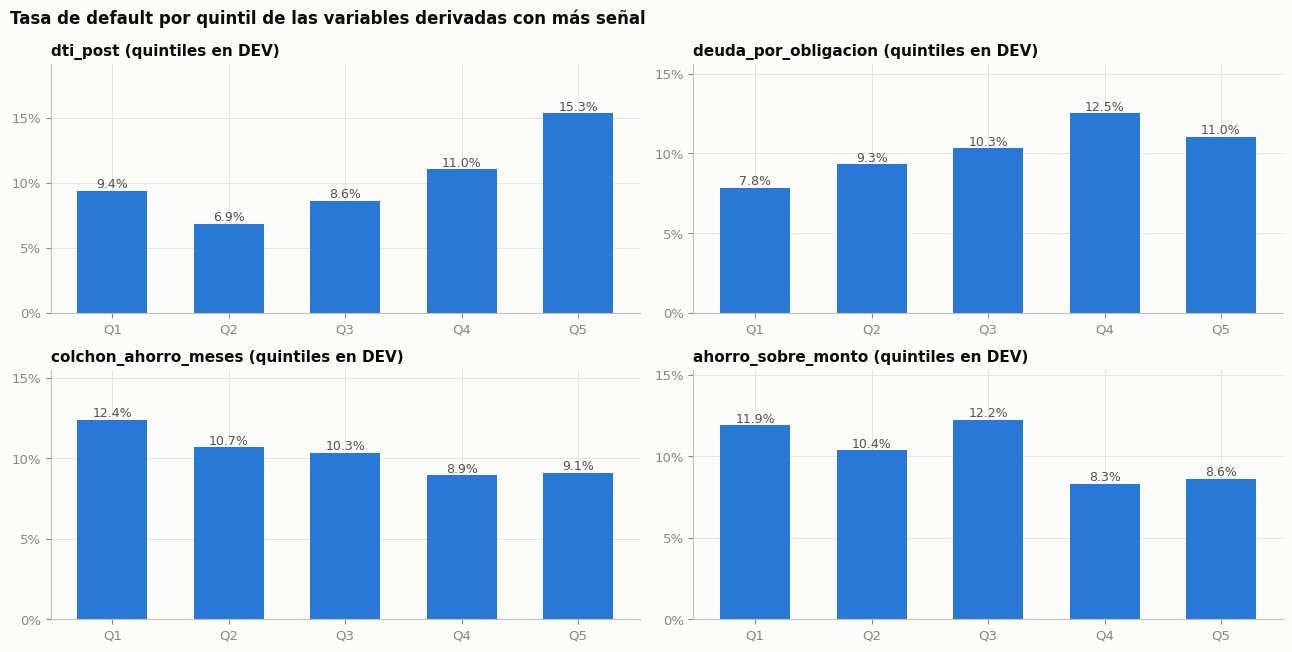

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.6))
for ax, col in zip(axes.ravel(), ["dti_post", "deuda_por_obligacion", "colchon_ahorro_meses", "ahorro_sobre_monto"]):
    d = pop_fx[pop_fx["sample"] == "DEV"]
    q = pd.qcut(d[col], 5, duplicates="drop")
    t = d.groupby(q, observed=True)[cfg.TARGET].agg(["size", "mean"])
    etiquetas = [f"Q{i+1}" for i in range(len(t))]
    ax.bar(etiquetas, t["mean"], color=BLUE, width=0.6)
    for x_, (v, n) in enumerate(zip(t["mean"], t["size"])):
        ax.text(x_, v, f"{v:.1%}", ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set_title(f"{col} (quintiles en DEV)")
    pct_axis(ax)
    ax.set_ylim(0, t["mean"].max() * 1.25)
fig.suptitle("Tasa de default por quintil de las variables derivadas con más señal",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.tight_layout()
savefig(fig, "fig10_features_derivadas")
plt.show()

**Qué muestra la evaluación:**

- **`dti_post` (AUC 0.570 en DEV)** iguala al `dti` original (0.571) pero es **más estable** entre muestras (0.570 / 0.538 / 0.580 frente a 0.571 / 0.533 / 0.613) y su lectura de negocio es directa: el último quintil tiene 15.3% de default frente a 6.9% del segundo. Es, además, la variable sobre la que se apoya la regla de capacidad de pago definida en 6.1.
- **`deuda_por_obligacion` (0.544)** es la derivada con mejor comportamiento fuera de muestra (0.573 en OOT) y el PSI más bajo de todas (0.002): separa al cliente con una deuda grande del que tiene varias chicas con el mismo pago total.
- **`colchon_ahorro_meses` (0.534)** ordena el riesgo de forma casi monótona y decreciente (12.4% en el primer quintil vs 9.1% en el último), como se espera de una medida de colchón financiero. **`ahorro_sobre_monto` (0.537)** apunta en la misma dirección, aunque con un quiebre en el tercer quintil: la relación existe pero no es monótona, y el binning del scorecard tendrá que resolverlo.
- **`dti_post_verificable` (0.547)** y **`excedente_per_capita` (0.537)** aportan señal moderada; su valor principal es de política (medir capacidad contra ingreso sustentable y contra el tamaño del hogar).
- Las derivadas de estacionalidad, faltantes e intensidad de búsqueda tienen AUC cercano a 0.51: se conservan por su racional (faltante informativo, riesgo de campaña agrícola), pero su aporte se decidirá con el análisis de IV en el scorecard.

Tres candidatas se **descartaron** tras medirlas:

In [14]:
display(features.discarded_doc())

,feature,formula,motivo_descarte
0,loan_to_income,requested_amount / monthly_income,Sin poder discriminante (AUC 0.501 en DEV) y m...
1,monto_vs_mediana_region,requested_amount / mediana del monto en la reg...,AUC 0.501 en DEV; además introduce un estadíst...
2,mes_originacion,mes calendario de observation_date,Reemplazada por campana_siembra: la señal esta...


## 9. Pipeline reproducible

Un único objeto de scikit-learn encadena: variables derivadas → winsorización → imputación → encoding. Se ajusta **solo con DEV** y se aplica igual a VAL, OOT y a cualquier solicitud nueva, que es lo que evita diferencias entre entrenamiento y producción.

In [15]:
num_cols, cat_cols_pipe = pipeline.model_columns()
cols_in = pipeline.pipeline_input_columns()   # esquema de entrada fijo (candidatas + fecha)
print(f"Entradas del pipeline: {len(cols_in)} columnas de la solicitud")
print(f"Salida esperada: {len(num_cols)} numéricas (incluye derivadas) + {len(cat_cols_pipe)} categóricas a one-hot")

pipe = pipeline.build_pipeline(scale=True)
dev, val, oot = (pop[pop["sample"] == s] for s in cfg.SAMPLE_ORDER)
pipe.fit(dev[cols_in])             # se ajusta SOLO con DEV
X_dev, X_val, X_oot = (pipe.transform(m[cols_in]) for m in (dev, val, oot))

print(f"Matriz resultante -> DEV {X_dev.shape} | VAL {X_val.shape} | OOT {X_oot.shape}")
print("Mismas columnas en las tres muestras:", list(X_dev.columns) == list(X_val.columns) == list(X_oot.columns))
print("Faltantes tras el pipeline:", int(X_dev.isna().sum().sum()), int(X_val.isna().sum().sum()), int(X_oot.isna().sum().sum()))
display(pipe)

Entradas del pipeline: 21 columnas de la solicitud
Salida esperada: 29 numéricas (incluye derivadas) + 3 categóricas a one-hot
Matriz resultante -> DEV (3443, 42) | VAL (1151, 42) | OOT (1189, 42)
Mismas columnas en las tres muestras: True
Faltantes tras el pipeline: 0 0 0


,steps,"[('features', ...), ('prep', ...)]"
,transform_input,None
,memory,None
,verbose,False
,annual_rate,None
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [16]:
# Control 1: los topes de winsorización se aprendieron en DEV y se aplican a OOT sin recalcularse.
winsor = pipe.named_steps["prep"].named_transformers_["num"].named_steps["winsor"]
topes = pd.DataFrame({"tope_inferior_p1": winsor.lower_, "tope_superior_p99": winsor.upper_})
display(topes.loc[["savings_balance", "monthly_debt_payment", "distance_to_branch_km", "requested_amount"]])
print("Máximo de savings_balance en OOT antes del pipeline:", f"{oot['savings_balance'].max():,.0f}")
print("Máximo tras el pipeline (escala estandarizada, ya acotado):", f"{X_oot['savings_balance'].max():.3f}")

# Control 2: ninguna variable prohibida entró a la matriz final.
prohibidas = set(data.forbidden_pd_features())
print("Variables prohibidas presentes en la matriz:", sorted(prohibidas & set(X_dev.columns)) or "ninguna")

# Control 3: el pipeline puede puntuar una solicitud individual, como lo hará el servicio de scoring.
una_solicitud = raw.iloc[[0]][cols_in]
print("Una sola solicitud transformada:", pipe.transform(una_solicitud).shape)

,tope_inferior_p1,tope_superior_p99
savings_balance,215.9754,"29,889.4206"
monthly_debt_payment,66.4990,"5,160.1310"
distance_to_branch_km,1.4000,57.5160
requested_amount,"1,295.9108","29,522.4966"


Máximo de savings_balance en OOT antes del pipeline: 66,016
Máximo tras el pipeline (escala estandarizada, ya acotado): 5.231
Variables prohibidas presentes en la matriz: ninguna
Una sola solicitud transformada: (1, 42)


Los tres controles son los que se van a auditar más adelante: los topes se aprenden una sola vez en DEV (el máximo de ahorros en OOT, S/ 66,016, queda acotado al tope de DEV de S/ 29,889), ninguna variable prohibida llega a la matriz, y el pipeline funciona con **una sola solicitud**, que es exactamente el modo en que lo llamará el servicio de scoring.

## 10. Data Dictionary técnico

Extiende el catálogo de 6.2 con las decisiones de tratamiento tomadas en esta sección.

In [17]:
dic_tec = data_dictionary.technical_dictionary()
display(dic_tec[["variable", "origen", "rol", "uso_pd", "transformacion", "imputacion", "encoding",
                 "riesgo_leakage", "uso_final"]])
dic_tec.to_csv(cfg.TABLES / "diccionario_tecnico.csv", index=False)
print(f"Variables documentadas: {len(dic_tec)} ({int((dic_tec.origen == 'Original del dataset').sum())} originales + "
      f"{int((dic_tec.origen == 'Derivada en 6.3').sum())} derivadas)")

,variable,origen,rol,uso_pd,transformacion,imputacion,encoding,riesgo_leakage,uso_final
0,application_id,Original del dataset,ID,No,No se transforma,No aplica,No aplica,No aplica,Trazabilidad del scoring
1,observation_date,Original del dataset,Tiempo,No,No se transforma,No aplica,No aplica,Ninguno si solo se usa para cortes temporales,Split DEV/VAL/OOT y seguimiento de cosechas
2,entity,Original del dataset,Metadato,No,No se transforma,No aplica,No aplica,No aplica,No se usa
3,product,Original del dataset,Metadato,No,No se transforma,No aplica,No aplica,No aplica,No se usa
4,age,Original del dataset,Solicitud,Candidata (fairness),Winsorización p1-p99 (topes ajustados en DEV),Mediana de DEV,No aplica (numérica),Bajo: medida en T0,Modelo PD sujeto a revisión de discriminación ...
5,region,Original del dataset,Solicitud,Candidata (fairness),No se transforma,Moda de DEV,One-hot; una categoría no vista en producción ...,Bajo: medida en T0,Modelo PD sujeto a revisión de discriminación ...
6,channel,Original del dataset,Proceso,Candidata,No se transforma,Moda de DEV,One-hot; una categoría no vista en producción ...,Bajo: medida en T0,Modelo PD
7,employment_type,Original del dataset,Solicitud,Candidata,No se transforma,Moda de DEV,One-hot; una categoría no vista en producción ...,Bajo: medida en T0,Modelo PD
8,monthly_income,Original del dataset,Solicitud,Candidata,Winsorización p1-p99 (topes ajustados en DEV),Mediana de DEV + indicador flag_sin_ingreso,No aplica (numérica),Medio: declarado y poco verificable; el riesgo...,Modelo PD
9,employment_tenure_months,Original del dataset,Solicitud,Candidata,Winsorización p1-p99 (topes ajustados en DEV);...,Mediana de DEV,No aplica (numérica),Bajo: medida en T0,Modelo PD


Variables documentadas: 55 (41 originales + 14 derivadas)


## 11. Persistencia y resumen de decisiones

In [18]:
cols_guardar = [cfg.ID_COL, cfg.DATE_COL, "sample", cfg.TARGET] + candidatas + features.DERIVED_FEATURES
pop_fx[cols_guardar].to_csv(cfg.DATA_PROCESSED / "pd_population_features.csv", index=False)
print("Guardado: data/processed/pd_population_features.csv", pop_fx[cols_guardar].shape)
print("Tablas nuevas:", sorted(p.name for p in cfg.TABLES.glob("*.csv") if p.name.startswith(("calidad_", "features_", "diccionario_"))))
print("Figuras nuevas:", sorted(p.name for p in cfg.FIGURES.glob("fig0[89]*.png")) + sorted(p.name for p in cfg.FIGURES.glob("fig10*.png")))

Guardado: data/processed/pd_population_features.csv (5783, 38)
Tablas nuevas: ['calidad_cardinalidad.csv', 'calidad_completitud.csv', 'calidad_estabilidad_psi.csv', 'calidad_outliers.csv', 'calidad_reglas_consistencia.csv', 'diccionario_tecnico.csv', 'features_derivadas_doc.csv', 'features_evaluacion.csv']
Figuras nuevas: ['fig08_winsorizacion.png', 'fig09_estabilidad_temporal.png', 'fig10_features_derivadas.png']


| Decisión | Definición adoptada | Evidencia |
|---|---|---|
| Faltantes | Imputación por mediana (numéricas) y moda (categóricas), ajustada en DEV, más indicadores de faltante para buró, ingreso y ahorro | Secciones 2 y 9 |
| Duplicados | Ninguna acción: no existen en la base | Sección 3 |
| Inconsistencias | Se conservan los registros; se acotan vía `antiguedad_relativa` y winsorización, y se reportan al equipo de captura | Sección 4 |
| Outliers | Winsorización p1-p99 con topes de DEV, sin eliminar registros | Sección 5 y `fig08` |
| Categóricas | One-hot simple (4-5 niveles, sin categorías raras); categorías no vistas quedan en ceros | Secciones 6 y 9 |
| Estabilidad | Variables estables (PSI máximo 0.017); el target sí se desplaza y exigirá recalibración | Sección 7 y `fig09` |
| Variables derivadas | 14 creadas y documentadas (12 candidatas + 2 insumos); 3 descartadas tras medirlas | Sección 8 y `fig10` |
| Pipeline | Un solo objeto ajustado en DEV, aplicable a una solicitud individual | Sección 9 |
| Diccionario técnico | 55 variables con transformación, imputación, encoding, riesgo de leakage y uso final | Sección 10 |